In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("Downloads/archive (3)/insurance.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


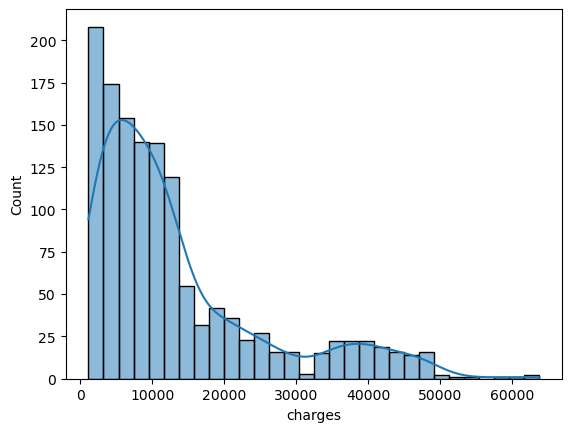

In [2]:
sns.histplot(df["charges"], kde =True)
plt.show()

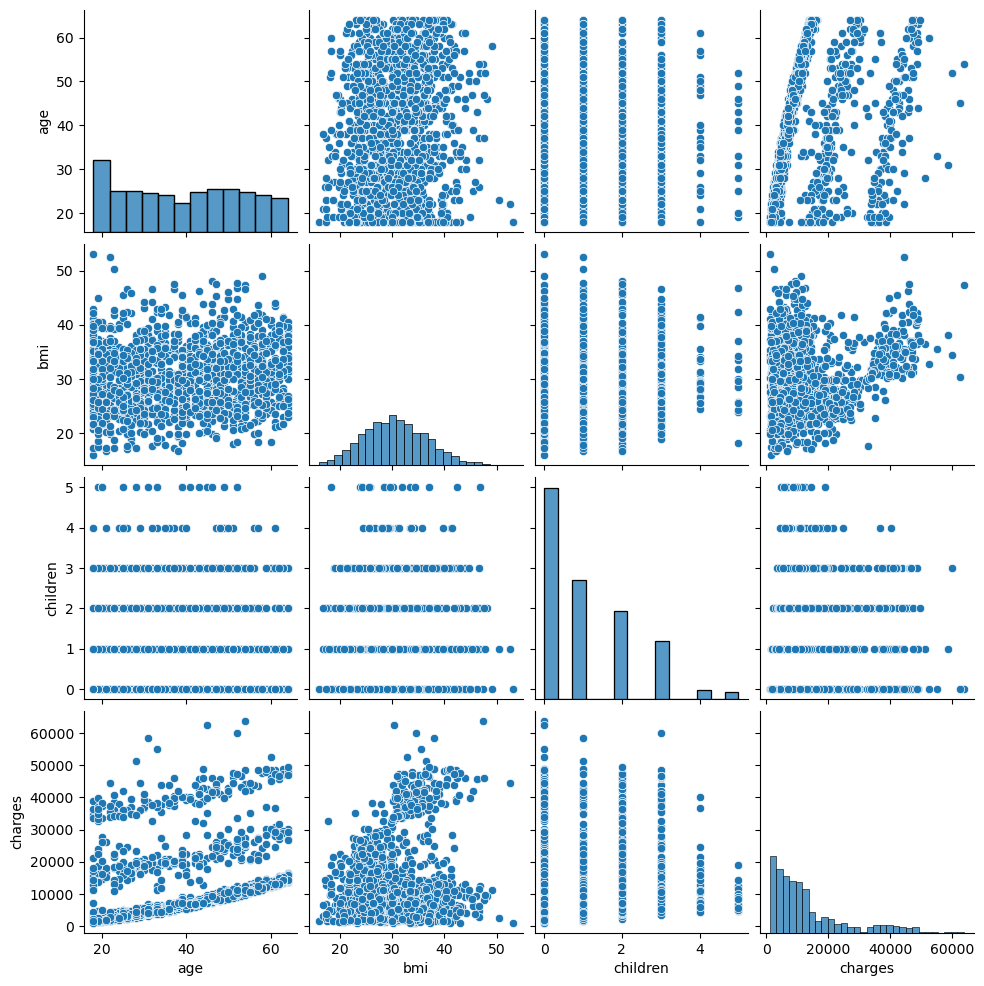

In [3]:
sns.pairplot(df)
plt.show()

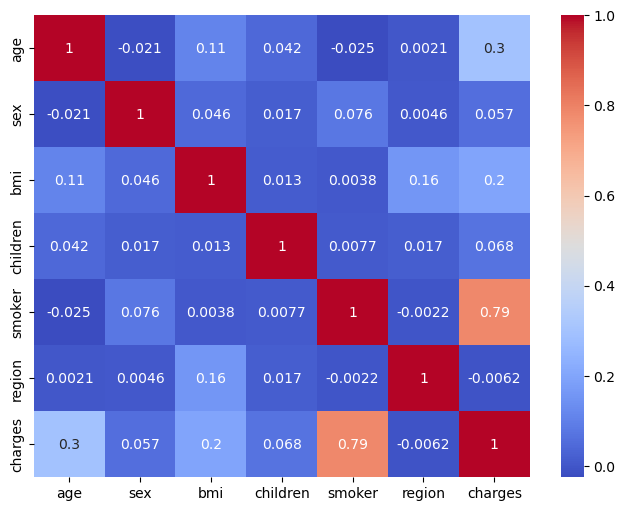

In [4]:
from sklearn.preprocessing import LabelEncoder

for col in ["sex", "smoker" , "region"]:
 df[col] = LabelEncoder().fit_transform(df[col])

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("charges" , axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
  X , y , test_size=0.3, random_state=23
)

print(X_train.shape, y_train.shape)

(936, 6) (936,)


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


intercept: -11775.88669841299
coefficients: [  245.94487173  -173.89871781   348.73926682   546.84795959
 24234.33665543  -524.00517078]


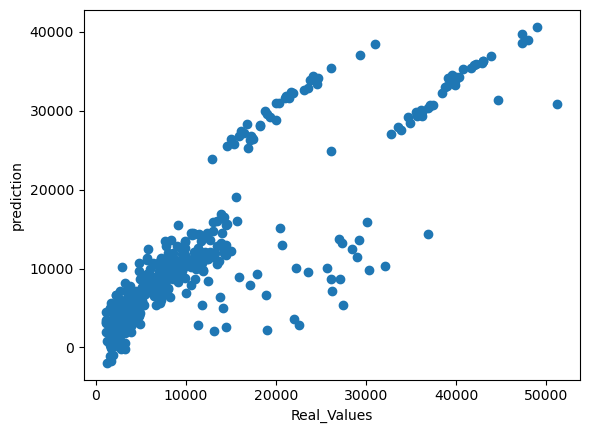

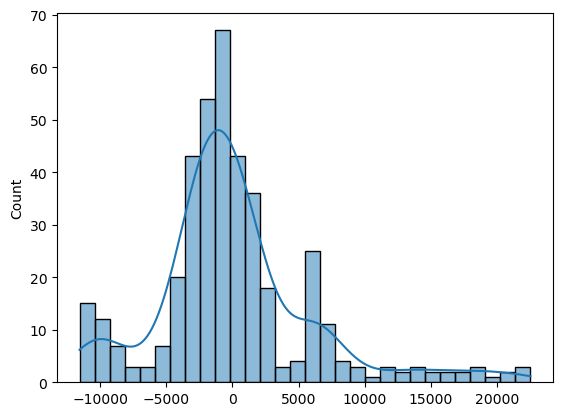

In [7]:
print("intercept:" , model.intercept_)
print("coefficients:" , model.coef_)

prediction = model.predict(X_test)
Real_Values = y_test.values

plt.scatter(Real_Values, prediction)
plt.xlabel("Real_Values")
plt.ylabel("prediction")
plt.show()

sns.histplot(Real_Values-prediction, kde=True)
plt.show()

In [10]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
import numpy as np

predictions = model.predict(X_test)
Real_Values = y_test.values

print("MAE:" , mean_absolute_error(Real_Values, predictions))
print ("MSE:" , mean_squared_error(Real_Values, predictions))
print("RMSE:" , np.sqrt(mean_squared_error(Real_Values , predictions)))
print ("R2:" , r2_score(Real_Values, predictions))

MAE: 4044.9876601373285
MSE: 35359546.654409066
RMSE: 5946.389379649559
R2: 0.7289379757416039


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=23)
rf.fit(X_train,y_train)
print("R2:", r2_score(y_test, rf.predict(X_test)))

R2: 0.8219690923622058


smoker      0.630838
bmi         0.206525
age         0.124571
children    0.020276
region      0.012312
sex         0.005477
dtype: float64


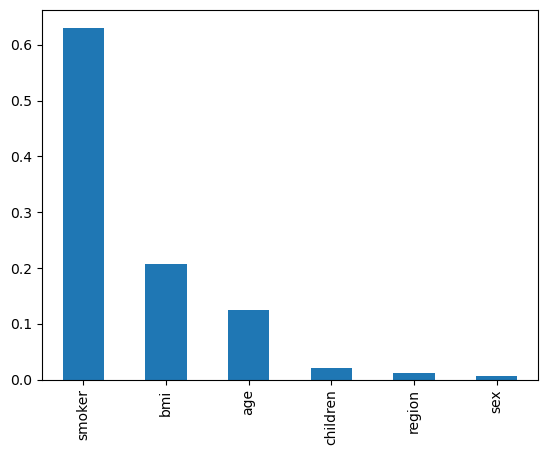

In [13]:
import pandas as pd
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp)
imp.plot(kind="bar")
plt.show()